# Employee Retention Analysis using HR data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


# Load dataset

In [2]:
from google.colab import files
uploaded = files.upload()

Saving HR_comma_sep.csv to HR_comma_sep.csv


In [3]:
df = pd.read_csv("HR_comma_sep.csv")

In [4]:
print(df.head())

   satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0                0.38             0.53               2                   157   
1                0.80             0.86               5                   262   
2                0.11             0.88               7                   272   
3                0.72             0.87               5                   223   
4                0.37             0.52               2                   159   

   time_spend_company  Work_accident  left  promotion_last_5years Department  \
0                   3              0     1                      0      sales   
1                   6              0     1                      0      sales   
2                   4              0     1                      0      sales   
3                   5              0     1                      0      sales   
4                   3              0     1                      0      sales   

   salary  
0     low  
1  medium  
2 

# Exploratory Data Analysis (EDA)

In [6]:
print("\nDataset Info")
print(df.info())


Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB
None


In [7]:
print("\nMissing Values")
print(df.isnull().sum())



Missing Values
satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
Department               0
salary                   0
dtype: int64


In [8]:
print("\nEmployee Retention Summary")
print(df.groupby('left').mean(numeric_only=True))


Employee Retention Summary
      satisfaction_level  last_evaluation  number_project  \
left                                                        
0               0.666810         0.715473        3.786664   
1               0.440098         0.718113        3.855503   

      average_montly_hours  time_spend_company  Work_accident  \
left                                                            
0               199.060203            3.380032       0.175009   
1               207.419210            3.876505       0.047326   

      promotion_last_5years  
left                         
0                  0.026251  
1                  0.005321  


#  Identify important variables

In [9]:
retention = df.groupby('left').mean(numeric_only=True)

print("\nRetention Analysis")
print(retention)



Retention Analysis
      satisfaction_level  last_evaluation  number_project  \
left                                                        
0               0.666810         0.715473        3.786664   
1               0.440098         0.718113        3.855503   

      average_montly_hours  time_spend_company  Work_accident  \
left                                                            
0               199.060203            3.380032       0.175009   
1               207.419210            3.876505       0.047326   

      promotion_last_5years  
left                         
0                  0.026251  
1                  0.005321  


# Salary impact on retention

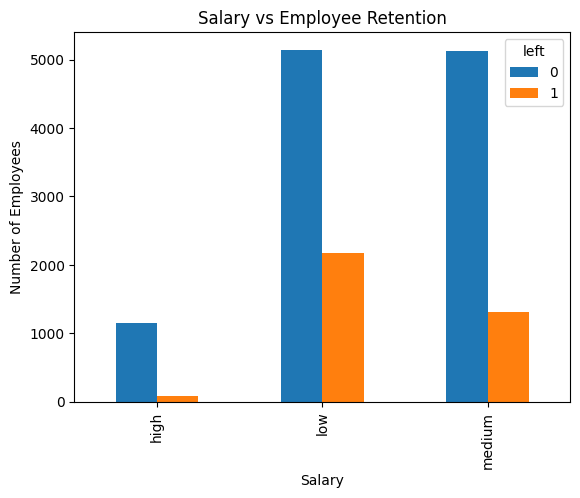

In [10]:
salary_retention = pd.crosstab(df.salary,df.left)

salary_retention.plot(kind='bar')

plt.title("Salary vs Employee Retention")
plt.xlabel("Salary")
plt.ylabel("Number of Employees")
plt.show()

# Department impact on retention

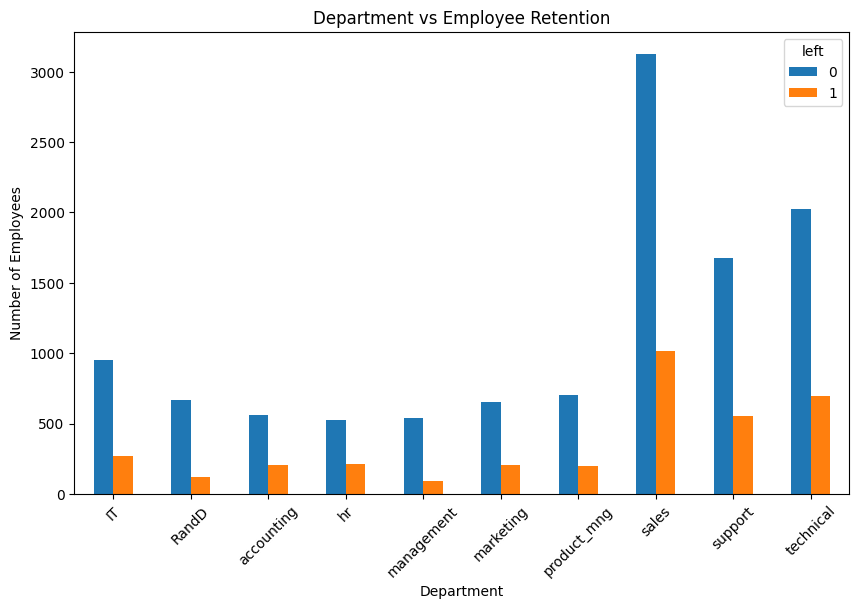

In [11]:
department_retention = pd.crosstab(df.Department,df.left)

department_retention.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Department vs Employee Retention")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.xticks(rotation=45)
plt.show()


# Build Logistic Regression Model

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Encode categorical features
df_model = df.copy()

le_dept = LabelEncoder()
le_salary = LabelEncoder()

df_model['Department'] = le_dept.fit_transform(df_model['Department'])
df_model['salary'] = le_salary.fit_transform(df_model['salary'])

# Use all features
X = df_model.drop('left', axis=1)
y = df_model['left']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Accuracy Percentage:", round(accuracy*100,2), "%")
